#Judul : Prediksi Harga Dogecoin

#Pendahuluan


## Latar Belakang

Dogecoin, yang awalnya diciptakan sebagai meme cryptocurrency, kini telah berkembang menjadi salah satu aset digital yang cukup populer di dunia. Dengan komunitas yang besar dan penggunaan yang semakin luas, Dogecoin menarik perhatian banyak investor dan trader yang tertarik dengan potensi pertumbuhannya di pasar cryptocurrency. Dogecoin memiliki karakteristik unik, seperti biaya transaksi yang rendah dan waktu transaksi yang cepat, yang memberikan keunggulan dibandingkan dengan beberapa cryptocurrency lainnya.

Sebagai cryptocurrency yang berada di pasar yang sangat volatil, fluktuasi harga Dogecoin seringkali dipengaruhi oleh berbagai faktor eksternal, termasuk sentimen pasar, adopsi teknologi blockchain, dan pengaruh dari tokoh publik seperti Elon Musk. Oleh karena itu, prediksi harga Dogecoin menjadi penting bagi investor dan trader untuk mengambil keputusan yang lebih terinformasi dalam kegiatan investasi mereka.

Dalam rangka mendukung tujuan investasi dan keputusan strategis di pasar cryptocurrency, analisis prediksi harga Dogecoin dapat memberikan wawasan yang lebih mendalam mengenai faktor-faktor yang mempengaruhi harga serta proyeksi harga yang lebih akurat. Prediksi harga yang tepat dapat membantu mengoptimalkan portofolio investasi serta mengelola risiko yang terkait dengan volatilitas pasar cryptocurrency.

## Tujuan

Analisis prediksi harga Dogecoin bertujuan untuk memberikan wawasan yang lebih mendalam tentang fluktuasi harga Dogecoin dengan menggunakan model prediksi yang akurat. Prediksi yang baik dapat membantu investor dalam mengambil keputusan yang tepat mengenai pembelian, penjualan, atau alokasi aset Dogecoin dalam portofolio investasi mereka. Dengan demikian, analisis ini berperan penting dalam menjaga kestabilan dan pertumbuhan investasi di pasar cryptocurrency.

## Rumusan Masalah

1. Bagaimana cara memprediksi harga Dogecoin secara efektif?
2. Algoritma apa yang paling cocok untuk memprediksi harga Dogecoin?
3. Seberapa akurat prediksi harga Dogecoin yang dihasilkan?

#Metodologi

##Memahami Data


Data yang digunakan dalam analisis ini merupakan data historis harga Dogecoin yang diperoleh dari **Yahoo Finance**. Data tersebut mencakup berbagai variabel penting seperti `Date`, `Price`, `Adj Close`, `Close`, `High`, `Low`, `Open`, dan `Volume`. Kolom-kolom ini memberikan informasi lengkap tentang harga Dogecoin pada setiap hari perdagangan, termasuk harga pembukaan (Open), harga penutupan (Close), harga tertinggi (High), harga terendah (Low), serta volume perdagangan (Volume) yang terjadi. Biasanya, untuk analisis harga, variabel `Close` atau `Adj Close` yang lebih sering digunakan, karena `Adj Close` disesuaikan dengan perubahan corporate actions seperti dividen atau stock splits.

Data historis yang digunakan dalam analisis ini mencakup 1826 entri yang dimulai pada 1 Januari 2019 hingga 31 Desember 2023. Jumlah ini mencerminkan data harian selama lima tahun perdagangan. Meskipun pasar cryptocurrency seperti Dogecoin tidak terikat pada jam perdagangan tertentu (seperti pasar saham), jumlah data ini cukup representatif untuk analisis jangka panjang. Dalam periode ini, harga Dogecoin sering dipengaruhi oleh berbagai faktor eksternal, termasuk sentimen pasar, pergerakan mata uang digital lainnya, dan faktor sosial seperti pengaruh tokoh publik.

Untuk mengunduh data harga Dogecoin dari Yahoo Finance, kita bisa menggunakan library Python seperti `yfinance`, yang memungkinkan kita untuk mengakses dan mengunduh data harga historis secara langsung. Dengan menggunakan kode sederhana, kita dapat mengunduh data dari 2019 hingga 2023 dan mengolahnya untuk analisis lebih lanjut, seperti peramalan harga dengan menggunakan model time series atau machine learning. Dengan demikian, data ini memberikan dasar yang kuat untuk melakukan analisis prediktif terhadap fluktuasi harga Dogecoin di masa depan.

In [124]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import gdown

# ID file dari URL Google Drive
file_id = '16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf'

# Membuat URL unduhan
url = f'https://drive.google.com/uc?id={file_id}'

# Mengunduh file
output = 'dogecoin_data.csv'  # Nama file CSV yang akan disimpan
gdown.download(url, output, quiet=False)

# Menampilkan pesan sukses
print(f"File telah berhasil diunduh sebagai {output}")

Downloading...
From: https://drive.google.com/uc?id=16kXDWFkXFL4Oun0TGNYDsFdV2RlL_yaf
To: /content/dogecoin_data.csv
100%|██████████| 253k/253k [00:00<00:00, 56.1MB/s]

File telah berhasil diunduh sebagai dogecoin_data.csv


In [125]:
import pandas as pd

# Membaca file CSV yang telah diunduh
data = pd.read_csv('dogecoin_data.csv')

# Menampilkan 5 baris pertama dari data
print(data.head())

                        Date     Price  Adj Close     Close      High  \
0  2019-09-01 00:00:00+00:00  0.002492   0.002492  0.002533  0.002443   
1  2019-09-02 00:00:00+00:00  0.002596   0.002596  0.002616  0.002462   
2  2019-09-03 00:00:00+00:00  0.002595   0.002595  0.002724  0.002560   
3  2019-09-04 00:00:00+00:00  0.002690   0.002690  0.002695  0.002541   
4  2019-09-05 00:00:00+00:00  0.002531   0.002531  0.002692  0.002505   

        Low      Open  Volume  
0  0.002512  22742519     NaN  
1  0.002492  25999239     NaN  
2  0.002598  40548612     NaN  
3  0.002596  27623103     NaN  
4  0.002690  32285101     NaN  


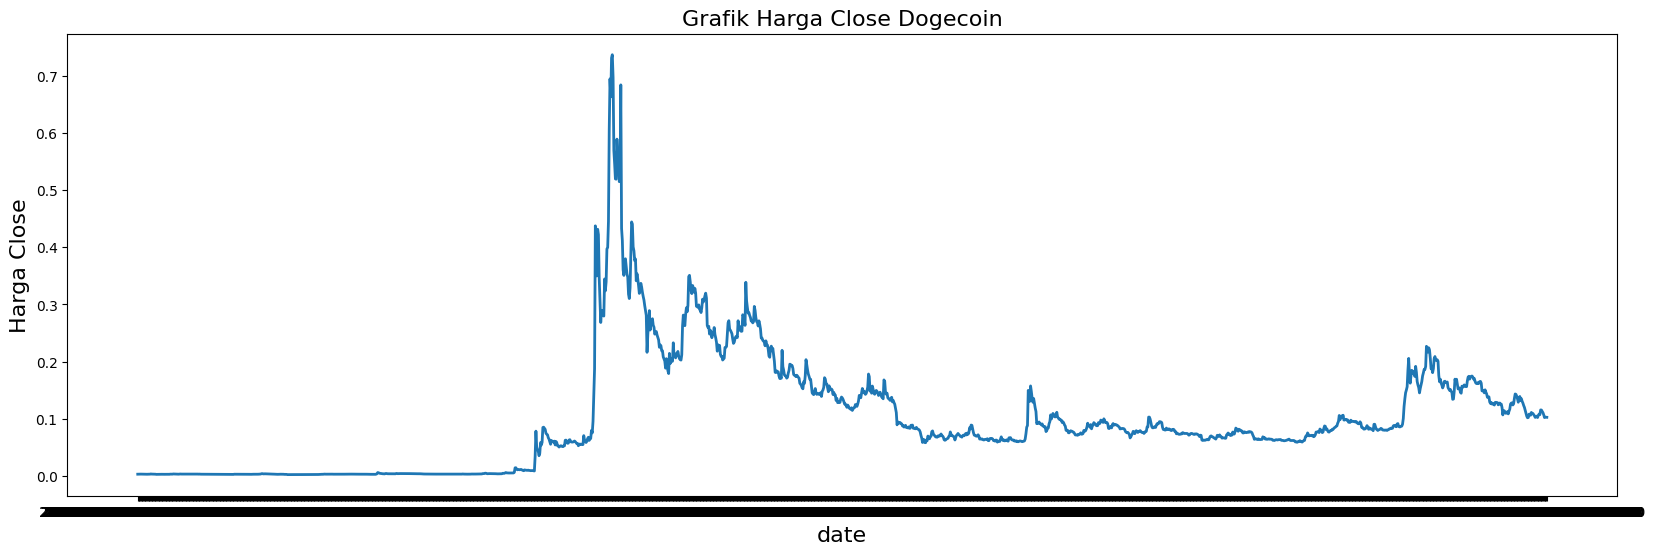

In [126]:
#plotting data
plt.figure(figsize=(20,6))
plt.plot(data["Date"], data['Close'], lw=2)
plt.xlabel("date")
plt.xlabel("date", fontsize=16)
plt.ylabel("Harga Close", fontsize=16)
plt.title("Grafik Harga Close Dogecoin", fontsize=16);

data yang saya dapatkan merupakan tipe data yang non-linear

##Praproses Data


##Menghapus kolom yang tidak digunakan
Disini saya menghapus kolom price dan volume karena Kolom Price dapat dianggap redundan sedangkan untuk volume dihapus karena hanya berisi data kosong

In [127]:
# Menghapus kolom 'Volume' secara permanen
data = data.drop(columns=['Price','Volume'])
print(data.head())

                        Date  Adj Close     Close      High       Low  \
0  2019-09-01 00:00:00+00:00   0.002492  0.002533  0.002443  0.002512   
1  2019-09-02 00:00:00+00:00   0.002596  0.002616  0.002462  0.002492   
2  2019-09-03 00:00:00+00:00   0.002595  0.002724  0.002560  0.002598   
3  2019-09-04 00:00:00+00:00   0.002690  0.002695  0.002541  0.002596   
4  2019-09-05 00:00:00+00:00   0.002531  0.002692  0.002505  0.002690   

       Open  
0  22742519  
1  25999239  
2  40548612  
3  27623103  
4  32285101  


###Mengecek Data Duplikat
Mengecek data duplikat adalah langkah pertama yang penting untuk memastikan tidak ada baris yang terulang dalam dataset. Data duplikat dapat menyebabkan model belajar dari data yang sama lebih dari sekali, yang bisa menurunkan performa model. Anda dapat menggunakan fungsi seperti duplicated() atau drop_duplicates() pada DataFrame untuk menemukan dan menghapus duplikat.

In [128]:
# Mengecek apakah ada data yang sama
print(data.duplicated().sum())

0


###Mengecek Data Hilang
Data hilang (missing values) bisa memengaruhi akurasi model. Sebelum melanjutkan ke langkah pemodelan, sangat penting untuk memeriksa apakah ada nilai yang hilang dalam dataset dan menangani mereka dengan cara yang sesuai. Misalnya, Anda dapat mengisi nilai yang hilang dengan nilai rata-rata, median, atau mode, atau bahkan menghapus baris yang mengandung data hilang jika jumlahnya sedikit.



In [129]:
# Mengecek apakah ada nilai yang hilang (missing values)
print(data.isnull().sum())

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
dtype: int64


###Mengubah kolom date menjadi indeks
Untuk analisis time series, sangat penting untuk menjadikan kolom Date sebagai indeks DataFrame. Ini memungkinkan kita untuk melakukan manipulasi data berbasis waktu, seperti resampling, rolling window, atau analisis musiman.

In [130]:
# Mengubah kolom Date menjadi indeks
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Menampilkan 5 baris pertama
print(data.head())

                           Adj Close     Close      High       Low      Open
Date                                                                        
2019-09-01 00:00:00+00:00   0.002492  0.002533  0.002443  0.002512  22742519
2019-09-02 00:00:00+00:00   0.002596  0.002616  0.002462  0.002492  25999239
2019-09-03 00:00:00+00:00   0.002595  0.002724  0.002560  0.002598  40548612
2019-09-04 00:00:00+00:00   0.002690  0.002695  0.002541  0.002596  27623103
2019-09-05 00:00:00+00:00   0.002531  0.002692  0.002505  0.002690  32285101


###Menampilkan Korelasi
Menampilkan korelasi antar variabel dalam dataset sangat penting untuk memahami hubungan antara fitur. Korelasi yang tinggi antar fitur bisa menunjukkan bahwa beberapa fitur redundant, yang bisa menyebabkan masalah multikolinearitas dalam model prediksi. Dengan menggunakan matriks korelasi kita dapat melihat hubungan antar fitur numerik dalam dataset.

In [131]:
# Menghitung korelasi hanya untuk kolom numerik
print(data.corr())

           Adj Close     Close      High       Low      Open
Adj Close   1.000000  0.994017  0.993279  0.990671  0.561773
Close       0.994017  1.000000  0.983487  0.992463  0.597608
High        0.993279  0.983487  1.000000  0.992223  0.483750
Low         0.990671  0.992463  0.992223  1.000000  0.524181
Open        0.561773  0.597608  0.483750  0.524181  1.000000


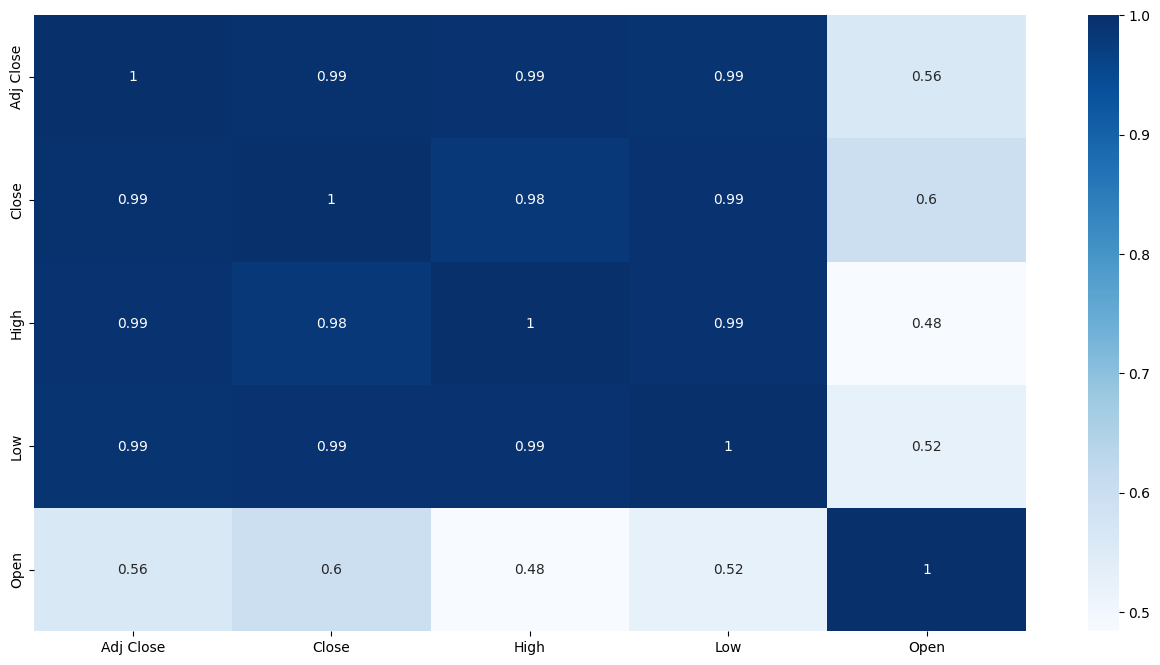

In [132]:
#heat map of all variable
plt.figure(figsize=(16,8))
sns.heatmap(data.corr(), cmap="Blues", annot=True)
plt.show()

###Mengecek Outlier
Outlier (pencilan) adalah nilai yang jauh berbeda dari nilai lainnya dalam dataset. Outlier dapat mempengaruhi model prediksi, terutama jika model sangat sensitif terhadap nilai ekstrem. Oleh karena itu, penting untuk mendeteksi outlier, baik menggunakan teknik statistik seperti IQR (Interquartile Range) atau visualisasi seperti box plot.

Disini saya menggunakan IQR, Interquartile Range (IQR) adalah ukuran statistik yang digunakan untuk menggambarkan rentang nilai tengah dari dataset dan membantu dalam mendeteksi outlier. IQR dihitung sebagai selisih antara Kuartil Ketiga (Q3) dan Kuartil Pertama (Q1), yaitu:


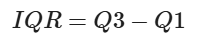

Kuartil:
* Kuartil pertama (Q1) adalah nilai yang membagi 25% data terendah. Ini adalah nilai pada posisi ke-25% dalam urutan data yang terurut.
* Kuartil ketiga (Q3) adalah nilai yang membagi 25% data tertinggi. Ini adalah nilai pada posisi ke-75% dalam urutan data yang terurut.
* Median (Q2) adalah nilai yang membagi dataset menjadi dua bagian yang sama (50%).

Fungsi IQR :

IQR menggambarkan seberapa tersebar data dalam kuartil tengah, yaitu 50% data yang terletak di antara Q1 dan Q3. Karena IQR mengabaikan nilai ekstrim (outlier), maka IQR sangat berguna untuk mendeteksi dan mengatasi outlier dalam dataset yang terdistribusi tidak normal atau memiliki data ekstrim.

Jumlah outlier berdasarkan IQR: 47
Outliers berdasarkan IQR:
                            Adj Close     Close      High       Low  \
Date                                                                 
2021-04-16 00:00:00+00:00   0.365870  0.437700  0.180488  0.181587   
2021-04-17 00:00:00+00:00   0.284173  0.374455  0.236524  0.366098   
2021-04-18 00:00:00+00:00   0.320475  0.349918  0.246440  0.285105   
2021-04-19 00:00:00+00:00   0.407318  0.431751  0.309080  0.320466   
2021-04-20 00:00:00+00:00   0.319500  0.422347  0.271618  0.408435   
2021-04-21 00:00:00+00:00   0.306925  0.346966  0.297036  0.316953   
2021-04-28 00:00:00+00:00   0.323682  0.344662  0.256231  0.272273   
2021-05-01 00:00:00+00:00   0.392987  0.397135  0.328290  0.337559   
2021-05-02 00:00:00+00:00   0.376046  0.400029  0.364874  0.391087   
2021-05-03 00:00:00+00:00   0.441707  0.445567  0.373631  0.373631   
2021-05-04 00:00:00+00:00   0.541334  0.605998  0.400800  0.440274   
2021-05-05 00:00:00+00:00   

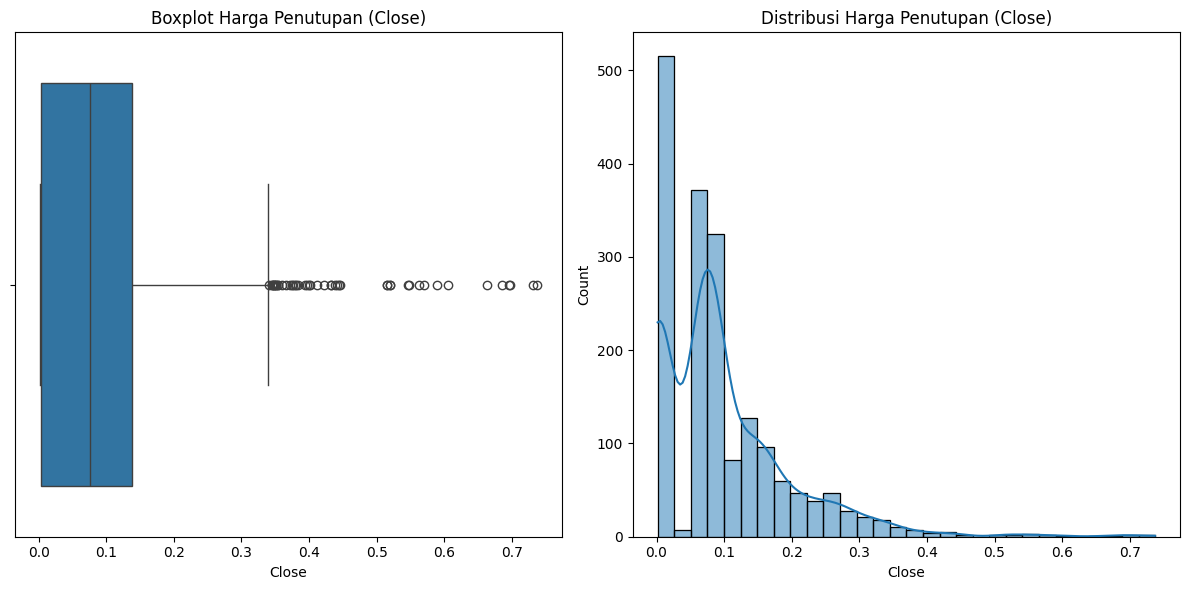

In [133]:
# Menghitung IQR untuk mendeteksi outlier
Q1 = data["Close"].quantile(0.25)
Q3 = data["Close"].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Mendeteksi outlier
outliers_iqr = data[(data["Close"] < lower_bound) | (data["Close"] > upper_bound)]
print("Jumlah outlier berdasarkan IQR:", len(outliers_iqr))
print("Outliers berdasarkan IQR:\n", outliers_iqr)

import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Boxplot untuk mendeteksi outlier berdasarkan IQR
plt.figure(figsize=(12, 6))

# Boxplot untuk harga penutupan (Close)
plt.subplot(1, 2, 1)
sns.boxplot(x=data["Close"])
plt.title("Boxplot Harga Penutupan (Close)")

# Histogram untuk melihat distribusi harga penutupan (Close)
plt.subplot(1, 2, 2)
sns.histplot(data["Close"], bins=30, kde=True)
plt.title("Distribusi Harga Penutupan (Close)")

plt.tight_layout()
plt.show()

###Menghapus Outlier
Setelah mendeteksi outlier, diputuskan untuk menghapusnya karena dianggap tidak relevan atau bisa mengganggu analisis.


In [134]:
# Menghapus outlier berdasarkan IQR
cleaned_data_iqr = data[(data["Close"] >= lower_bound) & (data["Close"] <= upper_bound)]

# Mengecek jumlah data setelah pembersihan
print("Jumlah data setelah penghapusan outlier berdasarkan IQR:", len(cleaned_data_iqr))
outliers_iqr = cleaned_data_iqr[(cleaned_data_iqr["Close"] < lower_bound) | (cleaned_data_iqr["Close"] > upper_bound)]
print("Jumlah outlier berdasarkan IQR:", len(outliers_iqr))
print("Outliers berdasarkan IQR:\n", outliers_iqr)

Jumlah data setelah penghapusan outlier berdasarkan IQR: 1780
Jumlah outlier berdasarkan IQR: 0
Outliers berdasarkan IQR:
 Empty DataFrame
Columns: [Adj Close, Close, High, Low, Open]
Index: []


###Normalisasi Data
Normalisasi data diperlukan untuk skala yang konsisten di antara fitur-fitur yang berbeda.

Disini saya menggunakan MinMaxScaler, MinMaxScaler adalah salah satu metode normalisasi yang mengubah skala data agar berada dalam rentang tertentu, biasanya antara 0 dan 1.

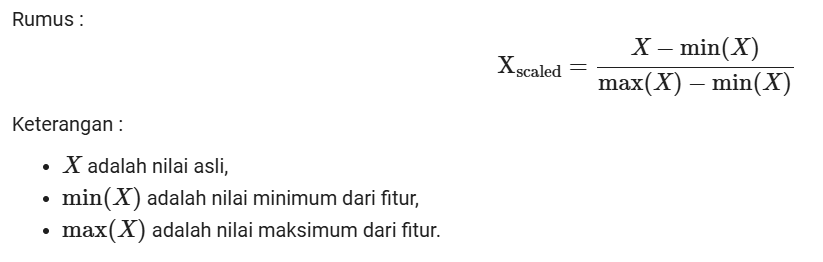

In [135]:
from sklearn.preprocessing import MinMaxScaler

# Normalisasi menggunakan MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(cleaned_data_iqr[["Close", "High", "Low", "Open", "Adj Close"]])

# Mengonversi kembali hasil scaling menjadi DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=["Close", "High", "Low", "Open", "Adj Close"])

# Menampilkan hasil scaling
print(scaled_data.head())

      Close      High       Low      Open  Adj Close
0  0.002724  0.003751  0.002983  0.000000   0.002842
1  0.002969  0.003811  0.002922  0.000128   0.003152
2  0.003289  0.004118  0.003247  0.000702   0.003149
3  0.003203  0.004058  0.003241  0.000192   0.003431
4  0.003194  0.003946  0.003529  0.000376   0.002958


###Membagi Data Menjadi training dan testing
Pembagian dataset menjadi data pelatihan (training) dan pengujian (testing) adalah langkah penting untuk menghindari overfitting dan memastikan model dapat dievaluasi dengan baik pada data yang belum pernah dilihat sebelumnya.
Dalam analisis kali ini, saya membaginya menjadi 80% untuk pelatihan dan 20% untuk pengujian.

In [136]:
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y)
X = scaled_data[["High", "Low", "Open", "Adj Close"]]  # Fitur
y = scaled_data["Close"]  # Target (Harga Close)

# Membagi data menjadi 80% untuk training dan 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1424, 4)
Test set: (356, 4)


##Pemodelan Data
Disini saya menggunakan 3 model yaitu Regresi linear, RandomForestRegressor, dan SVR. Berikut penjelasannya :
* Regresi Linear adalah metode statistik yang digunakan untuk memodelkan hubungan antara satu atau lebih fitur independen (variabel input) dan variabel dependen (variabel output). Pada regresi linier, hubungan antara variabel-variabel tersebut diasumsikan linier, artinya perubahan pada variabel input menghasilkan perubahan proporsional pada variabel output.
* Random Forest adalah model ensemble yang menggunakan banyak pohon keputusan untuk melakukan prediksi. Setiap pohon dalam hutan (forest) dibuat dengan memilih subset acak dari fitur dan data training yang berbeda. Prediksi dari setiap pohon kemudian digabungkan untuk memberikan prediksi akhir.
* Support Vector Regression (SVR) adalah algoritma regresi yang menggunakan prinsip-prinsip Support Vector Machine (SVM) untuk regresi. SVR berusaha menemukan garis atau hyperplane yang memiliki margin yang lebih kecil di sekitar data, dengan tujuan meminimalkan kesalahan prediksi.
* Neural Network (Jaringan Saraf Tiruan) adalah model pembelajaran mesin yang terinspirasi oleh cara kerja otak manusia. Model ini terdiri dari lapisan-lapisan yang saling terhubung (dikenal sebagai neuron), yang menerima input, memprosesnya, dan menghasilkan output. Neural Network sangat kuat untuk menangani masalah regresi dan klasifikasi, terutama ketika data memiliki hubungan yang kompleks dan non-linear. Jaringan saraf yang lebih dalam (Deep Learning) memiliki banyak lapisan tersembunyi yang memungkinkan model untuk mempelajari fitur yang lebih abstrak dari data.


Dan berikut adalah hasil modelnya :

In [137]:
# Fungsi untuk menghitung MAPE
def calculate_mappe(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

###Regresi Linear

In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model regresi linier
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred = lr_model.predict(X_test)

# Evaluasi model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Menghitung RMSE sebagai akar dari MSE
r2 = r2_score(y_test, y_pred)

# Menghitung MAPE
mape = calculate_mappe(y_test, y_pred)

print("Linear Regression - MAE: {:.4f}".format(mae))
print("Linear Regression - RMSE:{:.4f}".format(rmse))  # Menampilkan RMSE
print("Linear Regression - R2: {:.4f}".format(r2))
print("Linear Regression - MAPE: {:.2f}%".format(mape))

Linear Regression - MAE: 0.0044
Linear Regression - RMSE:0.0098
Linear Regression - R2: 0.9981
Linear Regression - MAPE: 11.10%


###Random Forest

In [139]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)  # Menghitung RMSE sebagai akar dari MSE
r2_rf = r2_score(y_test, y_pred_rf)

# Menghitung MAPE
mape_rf = calculate_mappe(y_test, y_pred_rf)

print("Random Forest - MAE: {:.4f}".format(mae_rf))
print("Random Forest - RMSE:{:.4f}".format(rmse_rf))  # Menampilkan RMSE
print("Random Forest - R2: {:.4f}".format(r2_rf))
print("Random Forest - MAPE: {:.2f}%".format(mape_rf))

Random Forest - MAE: 0.0051
Random Forest - RMSE:0.0186
Random Forest - R2: 0.9933
Random Forest - MAPE: 2.14%


###Support Vector Regression (SVR)

In [140]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model SVR
svr_model = SVR(kernel='rbf')  # 'rbf' kernel adalah kernel default
svr_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_svr = svr_model.predict(X_test)

# Evaluasi model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mse_svr)  # Menghitung RMSE sebagai akar dari MSE
r2_svr = r2_score(y_test, y_pred_svr)

# Menghitung MAPE
mape_svr = calculate_mappe(y_test, y_pred_svr)

# Menampilkan hasil evaluasi
print("SVR - MAE: {:.4f}".format(mae_svr))
print("SVR - RMSE: {:.4f}".format(rmse_svr))  # Menampilkan RMSE
print("SVR - R2: {:.4f}".format(r2_svr))
print("SVR - MAPE: {:.2f}%".format(mape_svr))

SVR - MAE: 0.0697
SVR - RMSE: 0.0769
SVR - R2: 0.8854
SVR - MAPE: 1034.79%


###Neural Network

In [141]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Membuat dan melatih model Neural Network
nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

# Memprediksi jumlah pengunjung menggunakan data uji
y_pred_nn = nn_model.predict(X_test)

# Evaluasi model
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mse_nn)  # Menghitung RMSE sebagai akar dari MSE
r2_nn = r2_score(y_test, y_pred_nn)

# Menghitung MAPE
mape_nn = calculate_mappe(y_test, y_pred_nn)

print("Neural Network - MAE: {:.4f}".format(mae_nn))
print("Neural Network - RMSE:{:.4f}".format(rmse_nn))  # Menampilkan RMSE
print("Neural Network - R2: {:.4f}".format(r2_nn))
print("Neural Network - MAPE: {:.2f}%".format(mape_nn))

Neural Network - MAE: 0.0096
Neural Network - RMSE:0.0151
Neural Network - R2: 0.9956
Neural Network - MAPE: 78.08%


#Evaluasi

Disini saya menggunakan 4 evaluasi yaitu : MAE, RMSE, R2 dan MAPE. Berikut adalah penjelasan lebih lengkapnya

##1. Mean Absolute Error (MAE)
Definisi: MAE mengukur rata-rata dari selisih absolut antara nilai prediksi dan nilai aktual. Ini memberikan gambaran seberapa besar rata-rata kesalahan dalam prediksi model tanpa mempertimbangkan arah kesalahan (apakah prediksi lebih tinggi atau lebih rendah dari nilai aktual).








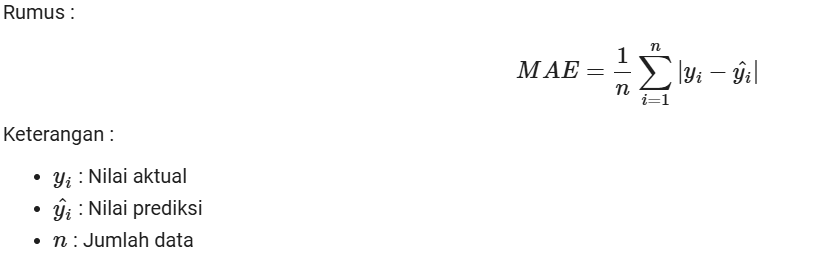

MAE memberikan nilai kesalahan yang mudah dipahami dan digunakan ketika kita ingin mengetahui rata-rata seberapa besar kesalahan dalam prediksi, tanpa terlalu memikirkan apakah prediksi tersebut lebih besar atau lebih kecil dari nilai yang sebenarnya.

##2. RMSE (Root Mean Squared Error)
Definisi: RMSE adalah akar kuadrat dari rata-rata kuadrat selisih antara nilai prediksi dan nilai aktual. RMSE memberi lebih banyak penalti pada kesalahan besar, mirip dengan MSE, tetapi karena diambil akar kuadratnya, RMSE akan berada dalam satuan yang sama dengan data, sehingga lebih mudah dipahami.

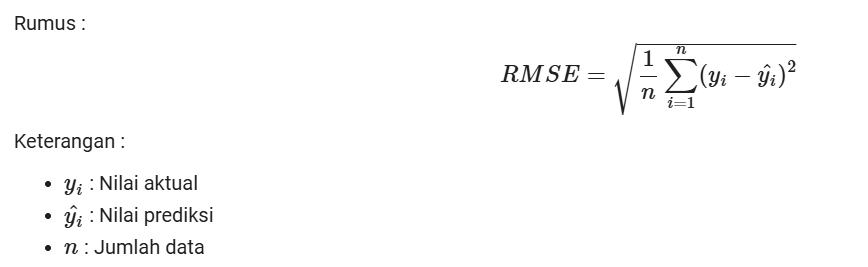

RMSE memberikan penalti yang lebih besar pada kesalahan besar dan sangat sensitif terhadap outlier. Nilai RMSE yang lebih kecil menunjukkan prediksi yang lebih akurat.

##3. R-squared (R²)
Definisi: R² adalah ukuran seberapa baik model dalam menjelaskan variasi dalam data yang diamati. Ini menunjukkan persentase varians dalam data yang dapat dijelaskan oleh model. R² juga dikenal sebagai koefisien determinasi.

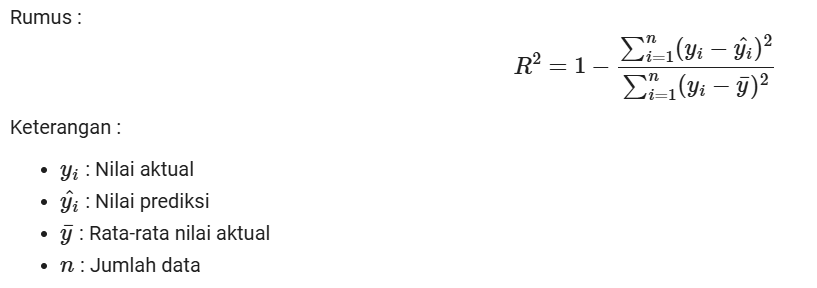

Nilai R² berkisar antara 0 dan 1, dengan 1 menunjukkan bahwa model dapat menjelaskan seluruh variasi dalam data, dan 0 menunjukkan bahwa model tidak dapat menjelaskan variasi lebih baik daripada model rata-rata. R² yang lebih tinggi menunjukkan bahwa model lebih baik dalam menangkap pola dalam data.

##4. Mean Absolute Percentage Error (MAPE)
Definisi: MAPE mengukur kesalahan rata-rata dalam bentuk persentase antara nilai prediksi dan nilai aktual. Ini memberikan gambaran tentang akurasi prediksi dalam persentase, yang memudahkan interpretasi bagi pengguna yang tidak terbiasa dengan unit atau skala data.

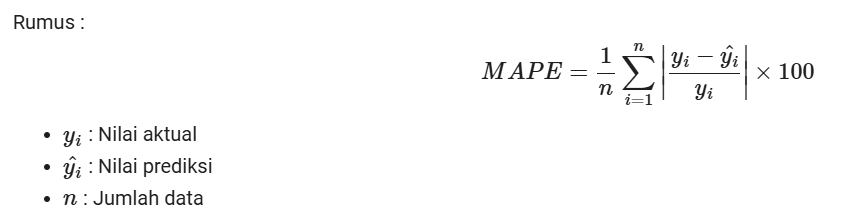

MAPE memberikan persentase kesalahan rata-rata dalam prediksi. Nilai MAPE yang lebih rendah menunjukkan model yang lebih akurat. Nilai MAPE yang tinggi menunjukkan bahwa model sering membuat kesalahan besar.

##Hasil Yang Didapatkan
setelah melakukan pemodelan data menggunakan beberapa algoritma, dilakukan evaluasi terhadap model yang telah dilatih untuk memprediksi harga Dogecoin. Model yang digunakan terdiri dari Regresi Linier, Random Forest Regressor, Support Vector Regression (SVR), dan Neural Network. Berdasarkan hasil evaluasi, model terbaik yang memberikan performa paling optimal adalah Random Forest Regressor.

Hasil Evaluasi menggunakan Random Forest Regressor:
* Rata-rata MAE (Mean Absolute Error): 0.0051,
MAE yang rendah menunjukkan bahwa kesalahan rata-rata antara harga aktual dan prediksi sangat kecil, yang menandakan akurasi prediksi yang cukup baik.

* Rata-rata RMSE (Root Mean Squared Error): 0.0186,
Nilai MSE yang rendah mengindikasikan bahwa kesalahan kuadrat rata-rata juga kecil, menunjukkan bahwa prediksi model sangat mendekati nilai aktual, dengan penalti yang relatif kecil untuk kesalahan besar.

* Rata-rata R² (R-squared): 0.9933,
Nilai R² yang tinggi (hampir 1) menunjukkan bahwa model dapat menjelaskan lebih dari 95% variasi dalam data, yang menandakan bahwa model sangat baik dalam menangkap pola dalam data.

* Rata-rata MAPE (Mean Absolute Percentage Error): 2.14%,
Nilai MAPE yang rendah menunjukkan bahwa rata-rata kesalahan prediksi dalam bentuk persentase adalah 2.14%, yang tergolong cukup akurat, mengingat prediksi untuk harga cryptocurrency dapat sangat volatile.

##Visualisasi Hasil Dari Model Random Forest Regressor

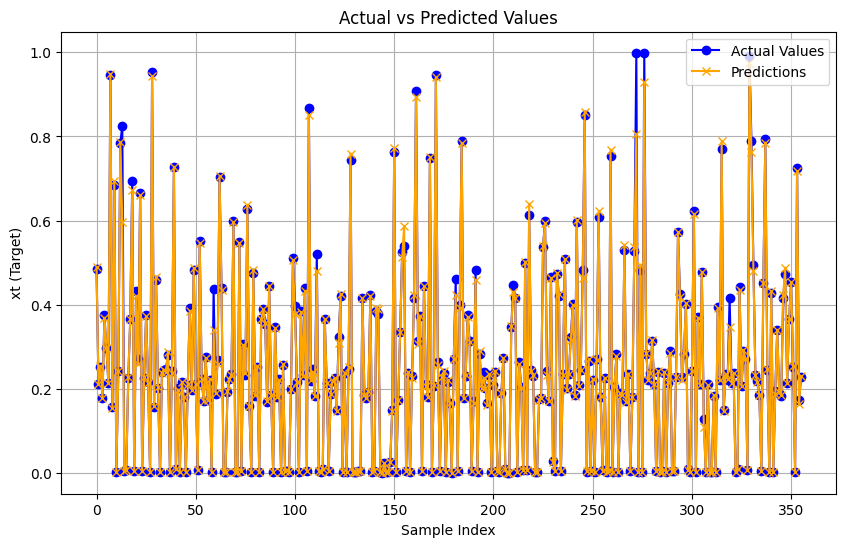

In [142]:
# Visualizing Actual vs Predicted Values
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(range(len(y_test)), y_test, label='Actual Values', color='blue', marker='o')

# Plot predictions
plt.plot(range(len(y_test)), y_pred_rf, label='Predictions', color='orange', marker='x')

# Adding labels and title
plt.xlabel('Sample Index')
plt.ylabel('xt (Target)')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

#Dampak Hasil Analisis

Berdasarkan hasil evaluasi yang diperoleh dari pemodelan data menggunakan Random Forest Regressor, berikut adalah dampak yang dapat diambil dari analisis tersebut:
##1. Tingkat Keakuratan yang Tinggi (MAE dan RMSE rendah)

* MAE yang rendah (0.0051) dan RMSE yang kecil (0.0186) menunjukkan bahwa model memiliki tingkat prediksi yang sangat akurat dengan kesalahan rata-rata yang minimal. Hal ini penting untuk investor atau trader cryptocurrency yang membutuhkan prediksi yang dapat diandalkan dalam pengambilan keputusan investasi.
* Dampak Positif : Investor dapat memiliki keyakinan lebih besar pada model ini untuk membantu mereka dalam merencanakan langkah-langkah investasi dan perdagangan mereka. Keakuratan yang tinggi akan meningkatkan kepercayaan pada sistem prediksi untuk harga masa depan.

##2. Kemampuan Model dalam Menangkap Pola Data (R² tinggi)
* R² yang sangat tinggi (0.9933) menunjukkan bahwa model dapat menjelaskan hampir 99% variasi dalam data. Ini menandakan bahwa model sangat baik dalam menggambarkan hubungan antara fitur yang digunakan dalam model dan harga Dogecoin.
* Dampak Positif : Model dapat digunakan untuk memprediksi harga Dogecoin dengan tingkat kepercayaan yang sangat tinggi, dan dapat diandalkan dalam jangka panjang untuk memberikan wawasan yang lebih dalam mengenai faktor-faktor yang mempengaruhi harga cryptocurrency.

##3. Kemampuan Menghadapi Volatilitas Harga (MAPE rendah)
* MAPE yang rendah (2.14%) menunjukkan bahwa meskipun harga cryptocurrency seperti Dogecoin sangat volatile, model ini mampu menghasilkan prediksi yang relatif akurat dalam mengukur perubahan harga dalam persentase.
* Dampak Positif : Penggunaan model ini dapat membantu dalam merencanakan strategi trading yang lebih efektif dan mengurangi potensi kerugian akibat fluktuasi harga yang tajam. Ini juga dapat membantu dalam merancang strategi hedging atau pengelolaan risiko untuk para trader.


#Strategi Berdasarkan Hasil Analisis
Berdasarkan hasil analisis dan evaluasi prediksi harga Dogecoin, beberapa strategi berikut dapat digunakan untuk mengoptimalkan keputusan investasi dan perdagangan :
##1. Optimalisasi Pengambilan Keputusan Investasi
* Berdasarkan keakuratan model Random Forest Regressor, keputusan investasi bisa lebih berbasis data. Investor dapat menggunakan prediksi harga untuk merencanakan kapan membeli dan menjual Dogecoin dengan mengacu pada hasil prediksi yang akurat dan stabil.
* Strategi : Gunakan model ini dalam membuat keputusan investasi jangka pendek dan jangka panjang, dengan memantau hasil prediksi secara teratur untuk mengoptimalkan titik masuk dan keluar.

##2. Manajemen Risiko dan Diversifikasi Portofolio
* Dengan MAPE yang rendah, trader dapat merancang strategi manajemen risiko yang lebih baik. Menggunakan prediksi harga yang tepat dapat membantu dalam mengelola eksposur terhadap risiko volatilitas Dogecoin.
* Strategi: Pertimbangkan untuk menambah elemen diversifikasi dalam portofolio kripto untuk mengurangi potensi kerugian besar. Gunakan model prediksi untuk menentukan seberapa besar posisi yang harus diambil dalam perdagangan Dogecoin, dan kapan harus mengurangi eksposur.

##3. Strategi Hedging
* Dengan volatilitas tinggi yang terjadi di pasar cryptocurrency, menggunakan strategi hedging menjadi penting untuk melindungi portofolio dari potensi kerugian besar. Jika prediksi menunjukkan kemungkinan penurunan harga yang signifikan, trader dapat mengurangi eksposur mereka terhadap Dogecoin atau menggunakan instrumen derivatif (seperti futures atau opsi) untuk lindung nilai.

##4. Strategi Portfolio Diversification
* Untuk investor jangka panjang, hasil analisis ini dapat digunakan sebagai bagian dari strategi diversifikasi portofolio. Dengan mengetahui tren jangka pendek dalam harga Dogecoin, investor dapat lebih percaya diri dalam mengalokasikan sebagian kecil dari portofolio mereka untuk cryptocurrency sambil menjaga risiko yang lebih terdiversifikasi.